# __Vetorização__
<font size=3>
    
A etapa de **vetorização** consiste na conversão de textos em representações numéricas que possam ser processadas por modelos de AM. Como os estes modelos não interpretam diretamente palavras ou frases, a vetorização transforma esses dados em formatos estruturados, como *one-hot encoding* (OHE), *Bag-of-Words* (BoW), *Term Frequency-Inverse Document Frequency* (TF-IDF) ou *token-embeddings*.

O *dicionário de vocabulário* é a base da vetorização. Durante a este processo, cada palavra do texto é mapeada para um índice ou vetor com base nesse vocabulário, garantindo que os textos sejam transformados de maneira consistente e padronizada para análise computacional.

## __1. Vetorização discreta:__
<font size=3>

Na aula passada, utilizamos o _dataset_ Zen of Python para indexar tokens, transformando cada lista de tokens (que compõe uma frase) em uma lista de índices correspondentes ao _dicionário de vocabulário_ $\texttt{vocab\_dict}$.

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import sys
sys.path.insert(0, '/content/drive/MyDrive/IMD1107 - Processamento de Linguagem Natural/1-unidade')

In [3]:
import numpy as np
from toolbox import ZenOfPython

In [4]:
dset = ZenOfPython()
dset.token_ids

[[1, 2, 3, 4, 5],
 [6, 2, 3, 4, 7],
 [8, 2, 3, 4, 9],
 [9, 2, 3, 4, 10],
 [11, 2, 3, 4, 12],
 [13, 2, 3, 4, 14],
 [15, 16],
 [17, 18, 19, 17, 20, 21, 22, 23, 24],
 [25, 26, 27, 28],
 [29, 30, 31, 32, 33],
 [34, 35, 36],
 [37, 23, 38, 39, 40, 41, 23, 42, 21, 43],
 [44, 30, 45, 46, 47, 48, 49, 50, 46, 47, 51, 52, 21, 53, 54],
 [25, 55, 52, 56, 57, 45, 51, 58, 59, 34, 60, 61],
 [62, 2, 3, 4, 31],
 [25, 31, 2, 63, 3, 4, 64, 62],
 [65, 23, 66, 2, 67, 21, 68, 69, 70, 71, 72],
 [65, 23, 66, 2, 73, 21, 68, 54, 56, 45, 70, 74, 72],
 [75, 76, 46, 77, 78, 72, 47, 79, 53, 80, 39, 81]]

### __1.1 *One-hot encoding* (OHE):__
<font size=3>
    
Este método *codifica* cada token em um **vetor binário** &mdash; do tamanho de $\texttt{vocab\_dict}$ &mdash; onde apenas uma posição tem o valor 1 (indicando a presença da palavra) e todas as outras posições são 0.  

Por exemplo, em um dicionário de vocabulário $\texttt{\{"cachorro":1, "gato":2, "pássaro":3, "peixe":4\}}$,

teríamos a codificação:

| Palavra   | Vetor One-Hot |
|-----------|--------------|
| cachorro  | `[1, 0, 0, 0]` |
| gato      | `[0, 1, 0, 0]` |
| pássaro   | `[0, 0, 1, 0]` |
| peixe     | `[0, 0, 0, 1]` |

Como consequência dessa vetorização, cada frase, ao ter seus tokens representados por vetores de números discretos, será transformada em uma **lista de listas**!

In [5]:
# Vamos considerar a primeira frase tokenizada do dataset (dset.dset_tokenized[0]):

print(f'Para a frase "{dset.texts[0]}", temos a indexação {dset.token_ids[0]}, o que nos dá em one-hot:\n')

for token in dset.dset_tokenized[0]:

    # Comprimento do vec é o comprimento do vocab + 1 (para incluir o índice 0 do vocab):
    vec = np.zeros((len(dset.vocab_dict) + 1), dtype="int16")

    i = dset.vocab_dict[token]

    vec[i] = 1

    print(f'{token}: {vec}\n')


Para a frase "Beautiful is better than ugly", temos a indexação [1, 2, 3, 4, 5], o que nos dá em one-hot:

beautiful: [0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]

is: [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]

better: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]

than: [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]

ugly: [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]



In [6]:
# Vetorização de todo dataset:

dset_vectorized = []

for token_list in dset.dset_tokenized:

    frase_vectorized = []

    for token in token_list:

        vec = np.zeros((len(dset.vocab_dict) + 1), dtype="int16")

        i = dset.vocab_dict[token]

        vec[i] = 1

        frase_vectorized.append(vec)

    dset_vectorized.append(frase_vectorized)


dset_vectorized[:2]

[[array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int16),
  array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int16),
  array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int16),
  array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0

### __1.2 *Bag-of-words* (BoW):__
<font size=3>

O "saco de palavras" **Bag-of-Words** (BoW) é um modelo de representação numérica de textos que simplifica a análise de textos ao *desconsiderar a ordem das palavras* e focar apenas na *frequência* com que elas aparecem. Para contabilizar os tokens, vamos utilizar a função $\texttt{Counter}$ da biblioteca $\texttt{collections}$ da seguinte forma:

In [7]:
from collections import Counter

In [8]:
# Vamos considerar só a primeira frase:
tokens = dset.dset_tokenized[0]

# Counter retornar um dicionário com a contagem de cada token:
bow = Counter(tokens)

print(bow)

Counter({'beautiful': 1, 'is': 1, 'better': 1, 'than': 1, 'ugly': 1})


In [9]:
# Para contabilizer todo o vocabulário, fazemos:
bow = Counter()

for token_list in dset.dset_tokenized:
    bow.update(token_list)

print(bow)

Counter({'is': 10, 'better': 8, 'than': 8, 'to': 5, 'the': 5, 'although': 3, 'never': 3, 'be': 3, 'one': 3, '': 3, 'idea': 3, 'complex': 2, 'special': 2, 'should': 2, 'unless': 2, 'of': 2, 'obvious': 2, 'way': 2, 'do': 2, 'it': 2, 'may': 2, 'now': 2, 'if': 2, 'implementation': 2, 'explain': 2, 'a': 2, 'beautiful': 1, 'ugly': 1, 'explicit': 1, 'implicit': 1, 'simple': 1, 'complicated': 1, 'flat': 1, 'nested': 1, 'sparse': 1, 'dense': 1, 'readability': 1, 'counts': 1, 'cases': 1, 'arent': 1, 'enough': 1, 'break': 1, 'rules': 1, 'practicality': 1, 'beats': 1, 'purity': 1, 'errors': 1, 'pass': 1, 'silently': 1, 'explicitly': 1, 'silenced': 1, 'in': 1, 'face': 1, 'ambiguity': 1, 'refuse': 1, 'temptation': 1, 'guess': 1, 'there': 1, 'and': 1, 'preferably': 1, 'only': 1, 'that': 1, 'not': 1, 'at': 1, 'first': 1, 'youre': 1, 'dutch': 1, 'often': 1, 'right': 1, 'hard': 1, 'its': 1, 'bad': 1, 'easy': 1, 'good': 1, 'namespaces': 1, 'are': 1, 'honking': 1, 'great': 1, 'lets': 1, 'more': 1, 'those'

In [10]:
# Podemos saber os tokens top n mais frequentes:

bow.most_common(n=3)

[('is', 10), ('better', 8), ('than', 8)]

<font size=3>

Com o modelo BoW, podemos realizar a vetorização de um texto com base na contagem dos tokens. Nesse modelo, cada frase ou documento é representado por um vetor de números inteiros, de tamanho do $\texttt{vocab\_dict}$. Cada posição do vetor indica a contagem/frequência de um token específico no texto (_lembrando que esse modelo desconsidera a ordem das posições das palavras_).

In [11]:
for token_list in dset.dset_tokenized:

    vec = np.zeros((len(dset.vocab_dict) + 1), dtype="int16")

    for token in token_list:
        # possição do token no vacabulário:
        i = dset.vocab_dict.get(token)

        # o token de na posição i recebe seu valor de frequência:
        vec[i] = bow.get(token)

    print(token_list)
    print(vec, "\n")


['beautiful', 'is', 'better', 'than', 'ugly']
[ 0  1 10  8  8  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0] 

['explicit', 'is', 'better', 'than', 'implicit']
[ 0  0 10  8  8  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0] 

['simple', 'is', 'better', 'than', 'complex']
[ 0  0 10  8  8  0  0  0  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0] 

['complex', 'is', 'better', 'than', 'complicated']
[ 0  0 10  8  8  0  0  0  0  2  1  0  0  0  0  0 

### __1.3 Vetorização OHE *vs* BoW:__
<font size=3>

| Característica                  | One-Hot Encoding                                                     | Bag-of-Words                                                                             |
| ------------------------------- | -------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| Tipo de representação           | Vetor binário (presença/ausência de palavra)                         | Contagem ou frequência de palavras                                                       |
| Considera a ordem das palavras? | Não                                                                  | Não                                                                                      |
| Escalabilidade                  | Escalabilidade ruim (vetores muito esparsos em grandes vocabulários) | Também cresce com o vocabulário, mas pode ser reduzido com TF-IDF ou seleção de features |
| Uso comum                       | Representação de tokens isolados ou categorias                       | Modelagem de documentos/textos completos                                                 |


## __2. Vetorização pela *frequência de termos*:__
<font size=3>

Nesse tipo de vetorização, iremos representar cada token com a sua *frequência* (**frequência do termo**) &mdash; o número de vezes que apareceu em um **documento** normalizado pelo tamanho do documento. Por razões didáticas, iremos considerar
 - **frases** do Zen of Python $\rightarrow$ **documentos**;
 - **dataset** $\rightarrow$ **_corpus_**.

Antes de prosseguir com a vetorização, vamos conhecer as métricas **TF-IDF** usadas para avaliar a importância de uma palavra em um documento em relação a uma coleção de documentos (*corpus*).

### __2.1 *Term frequency* (TF):__
<font size=3>

A **frequência do termo** (TF) mede quantas vezes uma palavra aparece em um documento, dado por

$$
    \text{TF}(t, d) = \frac{\text{Número de vezes que } t \text{ aparece em } d}{\text{Número total de termos em } d} \, ,
$$
onde $t$ é o termo (token) e $d$ é o documento.

Considere o **documento 1** ($d_1$) como a frase $\texttt{"Beautiful is better than ugly"}$, teremos que,

- Total de termos: 5  
- $\text{TF}(\texttt{"beautiful"},\, d_1) = 1/5 = 0.2$
- $\text{TF}(\texttt{"is"},\, d_1) = 1/5 = 0.2$
- $\text{TF}(\texttt{"better"},\, d_1) = 1/5 = 0.2$
- $\text{TF}(\texttt{"than"},\, d_1) = 1/5 = 0.2$
- $\text{TF}(\texttt{"ugly"},\, d_1) = 1/5 = 0.2$


In [12]:
def TF(doc):

    tf = {}
    doc_len = len(doc)

    bow = Counter(doc)

    for token in doc:
        counts = bow.get(token)

        tf[token] = counts/doc_len

    return tf


d1 = dset.dset_tokenized[0]

TF(d1)

{'beautiful': 0.2, 'is': 0.2, 'better': 0.2, 'than': 0.2, 'ugly': 0.2}

### __2.2 *Inverse Document Frequency* (IDF)__
<font size=3>

Já a **Frequência Inversa do Documento** (IDF) *penaliza* palavras que aparecem em muitos documentos (como *stopwords*). Ponderar o cálculo da frequência de tokens ajuda a extrair informações mesmo daqueles de baixa frequência.

$$
    \text{IDF}(t, D) = \log \left( \frac{\text{Número total de documentos } N}{\text{Número de documentos que contêm } t + 1} \right) \, ,
$$
onde $D = [d_1,\, d_2,\, \dots, d_N]$ é o _corpus_ (a coleção de documentos); o denominador apresenta "+1" para evitar divisão dividido por zero.

Sabendo que nosso _corpus_ (_dataset_) apresenta 19 documentos (frases),
- $\text{IDF}(\texttt{"beautiful"},\, D) = \log(19/(1+1)) = 2.2513$
- $\text{IDF}(\texttt{"is"},\, D) = \log(19/(10+1)) = 0.5464$

ou seja, o cálculo de IDF, o termo "is" será mais penalizado e o termo "beautiful" ficará mais evidente nas medições.

In [13]:
def IDF(docs, vocab):

    idf = {}
    N = len(docs)

    for token in vocab.keys():

        # número de documentos que aparece "token":
        counts = sum([1 for doc in docs if token in doc])

        idf[token] = float(np.log(N/(counts + 1)))

    return idf


D = dset.dset_tokenized

IDF(D, dset.vocab_dict)

{'beautiful': 2.2512917986064953,
 'is': 0.5465437063680699,
 'better': 0.7472144018302211,
 'than': 0.7472144018302211,
 'ugly': 2.2512917986064953,
 'explicit': 2.2512917986064953,
 'implicit': 2.2512917986064953,
 'simple': 2.2512917986064953,
 'complex': 1.8458266904983307,
 'complicated': 2.2512917986064953,
 'flat': 2.2512917986064953,
 'nested': 2.2512917986064953,
 'sparse': 2.2512917986064953,
 'dense': 2.2512917986064953,
 'readability': 2.2512917986064953,
 'counts': 2.2512917986064953,
 'special': 2.2512917986064953,
 'cases': 2.2512917986064953,
 'arent': 2.2512917986064953,
 'enough': 2.2512917986064953,
 'to': 1.1526795099383853,
 'break': 2.2512917986064953,
 'the': 1.33500106673234,
 'rules': 2.2512917986064953,
 'although': 1.55814461804655,
 'practicality': 2.2512917986064953,
 'beats': 2.2512917986064953,
 'purity': 2.2512917986064953,
 'errors': 2.2512917986064953,
 'should': 1.8458266904983307,
 'never': 1.55814461804655,
 'pass': 2.2512917986064953,
 'silently': 

### __2.3 TF-IDF:__
<font size=3>

Quando multiplicamos a **frequência do termo** pela **frequência inversa do documento** &mdash; podemos perceber abaixo &mdash; ainda que "is" seja o termo mais frequente nos documentos, sua importância é penalizada, permitindo que o termo "beautiful" se sobressaia na análise.


- $\text{TF-IDF}(\texttt{"beautiful"},\, d_1) = 0.2*2.2513 = 0.4502$
- $\text{TF-IDF}(\texttt{"is"},\, d_1) = 0.2*0.5464 = 0.1093$

Assim **TF-IDF** ajuda a identificar:
 - **Termos importantes:** Palavras com alta especificidade em um documento (alto IDF);
 - **Termos irrelevantes:** Palavras que aparecem em muitos documentos (IDF ≈ 0).


In [14]:
def TF_IDF(docs, vocab):

    idf = IDF(docs, vocab)

    tfidf_docs = []

    for doc in docs:
        tf = TF(doc)

        tfidf = {}
        for token in tf.keys():
            idf_value = idf[token]
            tf_value = tf[token]

            tfidf[token] = tf_value*idf_value

        tfidf_docs.append(tfidf)

    return tfidf_docs


tfidf_docs = TF_IDF(dset.dset_tokenized, dset.vocab_dict)
tfidf_docs[:2]

[{'beautiful': 0.4502583597212991,
  'is': 0.109308741273614,
  'better': 0.14944288036604422,
  'than': 0.14944288036604422,
  'ugly': 0.4502583597212991},
 {'explicit': 0.4502583597212991,
  'is': 0.109308741273614,
  'better': 0.14944288036604422,
  'than': 0.14944288036604422,
  'implicit': 0.4502583597212991}]

### __2.4 Vetorização por TF-IDF:__
<font size=3>

Na vetorização com TF-IDF, cada documento (frase) será representado por um vetor &mdash; do tamanho do vocabulário &mdash; onde a posição do termo leva o valor $\text{TF}\times\text{IDF}$.

In [15]:
dset_vectorized = []

for token_list, tfidf in zip(dset.dset_tokenized, tfidf_docs):

    vec = np.zeros((len(dset.vocab_dict) + 1))

    for token in token_list:
        i = dset.vocab_dict[token]

        vec[i] = tfidf[token]

    dset_vectorized.append(vec)

dset_vectorized = np.array(dset_vectorized)
print(dset_vectorized[0:2])

[[0.         0.45025836 0.10930874 0.14944288 0.14944288 0.45025836
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.10930874 0.14944288 0.14944288 0.
  0.45025836 0.45025836 0.         0.         0.         0.
  0.         0.         0.         0.        

### __2.5 Vetorização TF-IDF com $\texttt{sklearn}$:__
<font size=3>

Utilizando a função `TfidfVectorizer` da biblioteca **scikit-learn**, obteremos resultados similares.

In [16]:
dset.texts

['Beautiful is better than ugly',
 'Explicit is better than implicit',
 'Simple is better than complex',
 'Complex is better than complicated',
 'Flat is better than nested',
 'Sparse is better than dense',
 'Readability counts',
 "Special cases aren't special enough to break the rules",
 'Although practicality beats purity',
 'Errors should never pass silently',
 'Unless explicitly silenced',
 'In the face of ambiguity, refuse the temptation to guess',
 'There should be one - and preferably only one - obvious way to do it',
 "Although that way may not be obvious at first unless you're Dutch",
 'Now is better than never',
 'Although never is often better than right now',
 "If the implementation is hard to explain, it's a bad idea",
 'If the implementation is easy to explain, it may be a good idea',
 "Namespaces are one honking great idea - let's do more of those!"]

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

# O objeto X contém todas as informações da vetorização
X = vectorizer.fit_transform(dset.texts)

vocab = vectorizer.get_feature_names_out()

vocab

array(['although', 'ambiguity', 'and', 'are', 'aren', 'at', 'bad', 'be',
       'beats', 'beautiful', 'better', 'break', 'cases', 'complex',
       'complicated', 'counts', 'dense', 'do', 'dutch', 'easy', 'enough',
       'errors', 'explain', 'explicit', 'explicitly', 'face', 'first',
       'flat', 'good', 'great', 'guess', 'hard', 'honking', 'idea', 'if',
       'implementation', 'implicit', 'in', 'is', 'it', 'let', 'may',
       'more', 'namespaces', 'nested', 'never', 'not', 'now', 'obvious',
       'of', 'often', 'one', 'only', 'pass', 'practicality', 'preferably',
       'purity', 're', 'readability', 'refuse', 'right', 'rules',
       'should', 'silenced', 'silently', 'simple', 'sparse', 'special',
       'temptation', 'than', 'that', 'the', 'there', 'those', 'to',
       'ugly', 'unless', 'way', 'you'], dtype=object)

In [18]:
X.toarray()[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.59473243,
       0.32387685, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.28773989, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.32387685,
       0.        , 0.        , 0.        , 0.        , 0.     

In [19]:
import pandas as pd

In [20]:
# Criando dataframe da vetorização:
df_tfidf = pd.DataFrame(data=X.toarray(), columns=vocab)
df_tfidf

,although,ambiguity,and,are,aren,at,bad,be,beats,beautiful,...,than,that,the,there,those,to,ugly,unless,way,you
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.594732,...,0.323877,0.000000,0.000000,0.000000,0.000000,0.000000,0.594732,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.323877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.337944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.337944,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.323877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.323877,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.316744,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.228864,0.000000,0.000000,0.211378,0.000000,0.000000,0.000000,0.000000
8,0.415032,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.525277,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## **3. A Lei de Zipf:**
<font size=3>

Até agora, vimos como transformar textos em números baseando-se na **frequência** das palavras. Mas será que a distribuição dessas frequências é aleatória?

<font size=3>

Na década de 1930, o linguista George Kingsley Zipf notou um padrão matemático fascinante e universal na linguagem humana, que ficou conhecido como a **Lei de Zipf**. Ele descobriu que, **em qualquer corpus de texto natural, a frequência de uma palavra é inversamente proporcional à sua posição (_ranking_) na tabela de frequências.**

### **3.1 Formulação Matemática:**
<font size=3>

A Lei de Zipf pode ser expressa por
$$
    f(r) \propto \frac{1}{r} \, ,
$$
onde **$f$** é a frequência da palavra no texto, e **$r$** é o *ranking* (posição) da palavra (1 para a mais frequente, 2 para a segunda mais frequente, etc.).

> Em termos práticos, isso significa que a palavra mais comum de um idioma aparece o dobro de vezes que a segunda mais comum, o triplo de vezes que a terceira mais comum, e assim por diante. Se a palavra no rank 1 aparece 1.000 vezes, a do rank 10 aparecerá aproximadamente 100 vezes.

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
# definindo o vetorizador BoW para calcular a frequência dos tokens:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(dset.texts)

vocab = vectorizer.get_feature_names_out()

df_bow = pd.DataFrame(data=X.toarray(), columns=vocab)

# somando as ocorrências de cada palavra em todo o corpus (soma das colunas):
frequencias = df_bow.sum(axis=0)

# ordenando os valores da maior frequência para a menor:
frequencias_ordenadas = frequencias.sort_values(ascending=False)

# criar um dataframe específico para a Lei de Zipf:
df_zipf = pd.DataFrame({'Frequencia': frequencias_ordenadas,
                        'Rank': range(1, len(frequencias_ordenadas) + 1)})

df_zipf.head(10)

,Frequencia,Rank
is,10,1
than,8,2
better,8,3
to,5,4
the,5,5
be,3,6
although,3,7
never,3,8
idea,3,9
it,3,10


In [23]:
import matplotlib.pyplot as plt

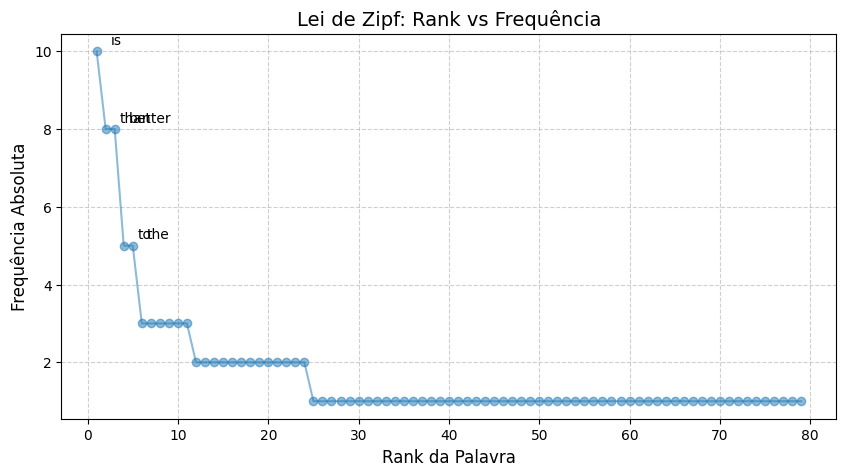

In [24]:
plt.figure(figsize=(10, 5))

plt.title('Lei de Zipf: Rank vs Frequência', fontsize=14)
plt.plot(df_zipf['Rank'], df_zipf['Frequencia'], marker='o', linestyle='-', alpha=0.5)

# anotando as top 5 palavras no gráfico para visualização:
for i in range(min(5, len(df_zipf))):
    palavra = df_zipf.index[i]
    rank = df_zipf['Rank'].iloc[i]
    freq = df_zipf['Frequencia'].iloc[i]

    plt.annotate(palavra, (rank, freq), textcoords="offset points", xytext=(10,5), ha='left')

plt.xlabel('Rank da Palavra', fontsize=12)
plt.ylabel('Frequência Absoluta', fontsize=12)
plt.grid(linestyle='--', alpha=0.6)
plt.show()

<font size=3>

> **Observe que** mesmo em um texto minúsculo de 19 linhas, a matemática da linguagem já começa a aparecer, Temos poucas palavras no topo (como 'is', 'better', 'than') e uma enorme quantidade de palavras que aparecem apenas uma vez na cauda do gráfico. Em um livro inteiro, essa curva ficaria perfeitamente lisa!


### **3.2 A Relação com as _Stop Words_ e o TF-IDF:**
<font size=3>

Ao observar o gráfico acima, notamos a formação de uma "cauda longa". Esse comportamento matemático explica e justifica duas das técnicas mais importantes em Processamento de Linguagem Natural:

1. **O problema do Topo do Gráfico (_stop words_):** A ponta esquerda e mais alta do gráfico é sempre dominada por um grupo minúsculo de palavras que aparecem o tempo todo (artigos, preposições, conjunções). Como elas estão em quase todos os documentos, elas não ajudam os algoritmos a diferenciar o assunto dos textos. É exatamente por isso que aplicamos a **remoção de _stop words_**, cortando essa "cabeça" do gráfico.

2. **A motivação para o TF-IDF:** A Lei de Zipf mostra que contar palavras cruamente (_Bag-of-Words_) dá um poder desproporcional às palavras comuns. O **TF-IDF** foi criado justamente para penalizar essas palavras hiperfrequentes (o topo do ranking) e dar um peso maior às palavras que estão no "meio" e na "cauda" do gráfico, pois são elas que geralmente carregam o verdadeiro significado (a semântica) da frase.

## __Referências:__
<font size=3>

 - **(3.1-3.2)**: [Natural Language Processing in Action](https://www.manning.com/books/natural-language-processing-in-action).
   